In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer,AutoModelForCausalLM,DataCollatorForSeq2Seq,TrainingArguments,Trainer

In [2]:
import datasets
datasets.__version__

'3.1.0'

In [3]:
import transformers
transformers.__version__

'4.46.3'

In [4]:
import warnings
warnings.filterwarnings('ignore')

#加载数据集

In [5]:
import os
data_dir = os.path.expanduser("~/datasets/alpaca-gpt4-data-zh")
ds = load_dataset("json",data_dir=data_dir,split="train")
ds

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 48818
})

In [6]:
ds[:3]

{'instruction': ['保持健康的三个提示。', '三原色是什么？', '描述原子的结构。'],
 'input': ['', '', ''],
 'output': ['以下是保持健康的三个提示：\n\n1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。\n\n2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。\n\n3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。',
  '三原色通常指的是红色、绿色和蓝色（RGB）。它们是通过加色混合原理创建色彩的三种基础颜色。在以发光为基础的显示设备中（如电视、计算机显示器、智能手机和平板电脑显示屏）, 三原色可混合产生大量色彩。其中红色和绿色可以混合生成黄色，红色和蓝色可以混合生成品红色，蓝色和绿色可以混合生成青色。当红色、绿色和蓝色按相等比例混合时，可以产生白色或灰色。\n\n此外，在印刷和绘画中，三原色指的是以颜料为基础的红、黄和蓝颜色（RYB）。这三种颜色用以通过减色混合原理来创建色彩。不过，三原色的具体定义并不唯一，不同的颜色系统可能会采用不同的三原色。',
  '原子是物质的基本单位，它由三种基本粒子组成：质子、中子和电子。质子和中子形成原子核，位于原子中心，核外的电子围绕着原子核运动。\n\n原子结构具有层次性。原子核中，质子带正电，中子不带电（中性）。原子核非常小且致密，占据了原子总质量的绝大部分。电子带负电，通常围绕核运动，形成若干层次，称为壳层或电子层。电子数量与质子数量相等，使原子呈电中性。\n\n电子在每个壳层中都呈规律分布，并且不同壳层所能容纳的电子数也不同。在最里面的壳层一般只能容纳2个电子，其次一层最多可容纳8个电子，再往外的壳层可容纳的电子数逐层递增。\n\n原子核主要受到两种相互作用力的影响：强力和电磁力。强力的作用范围非常小，主要限制在原子核内，具有极强的吸引作用，使核子（质子和中子）紧密结合在一起。电磁力的作用范围较大，主要通过核外的电子与原子核相互作用，发挥作用。\n\n这就是原子的基本结构。原子内部结构复杂多样，不同元素的原子核中质子、中子数量不同

# 数据集预处理

In [7]:
model_path = os.path.expanduser("~/models/bloom-1b4-zh")
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer

BloomTokenizerFast(name_or_path='/Users/daijunjie/models/bloom-1b4-zh', vocab_size=46145, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

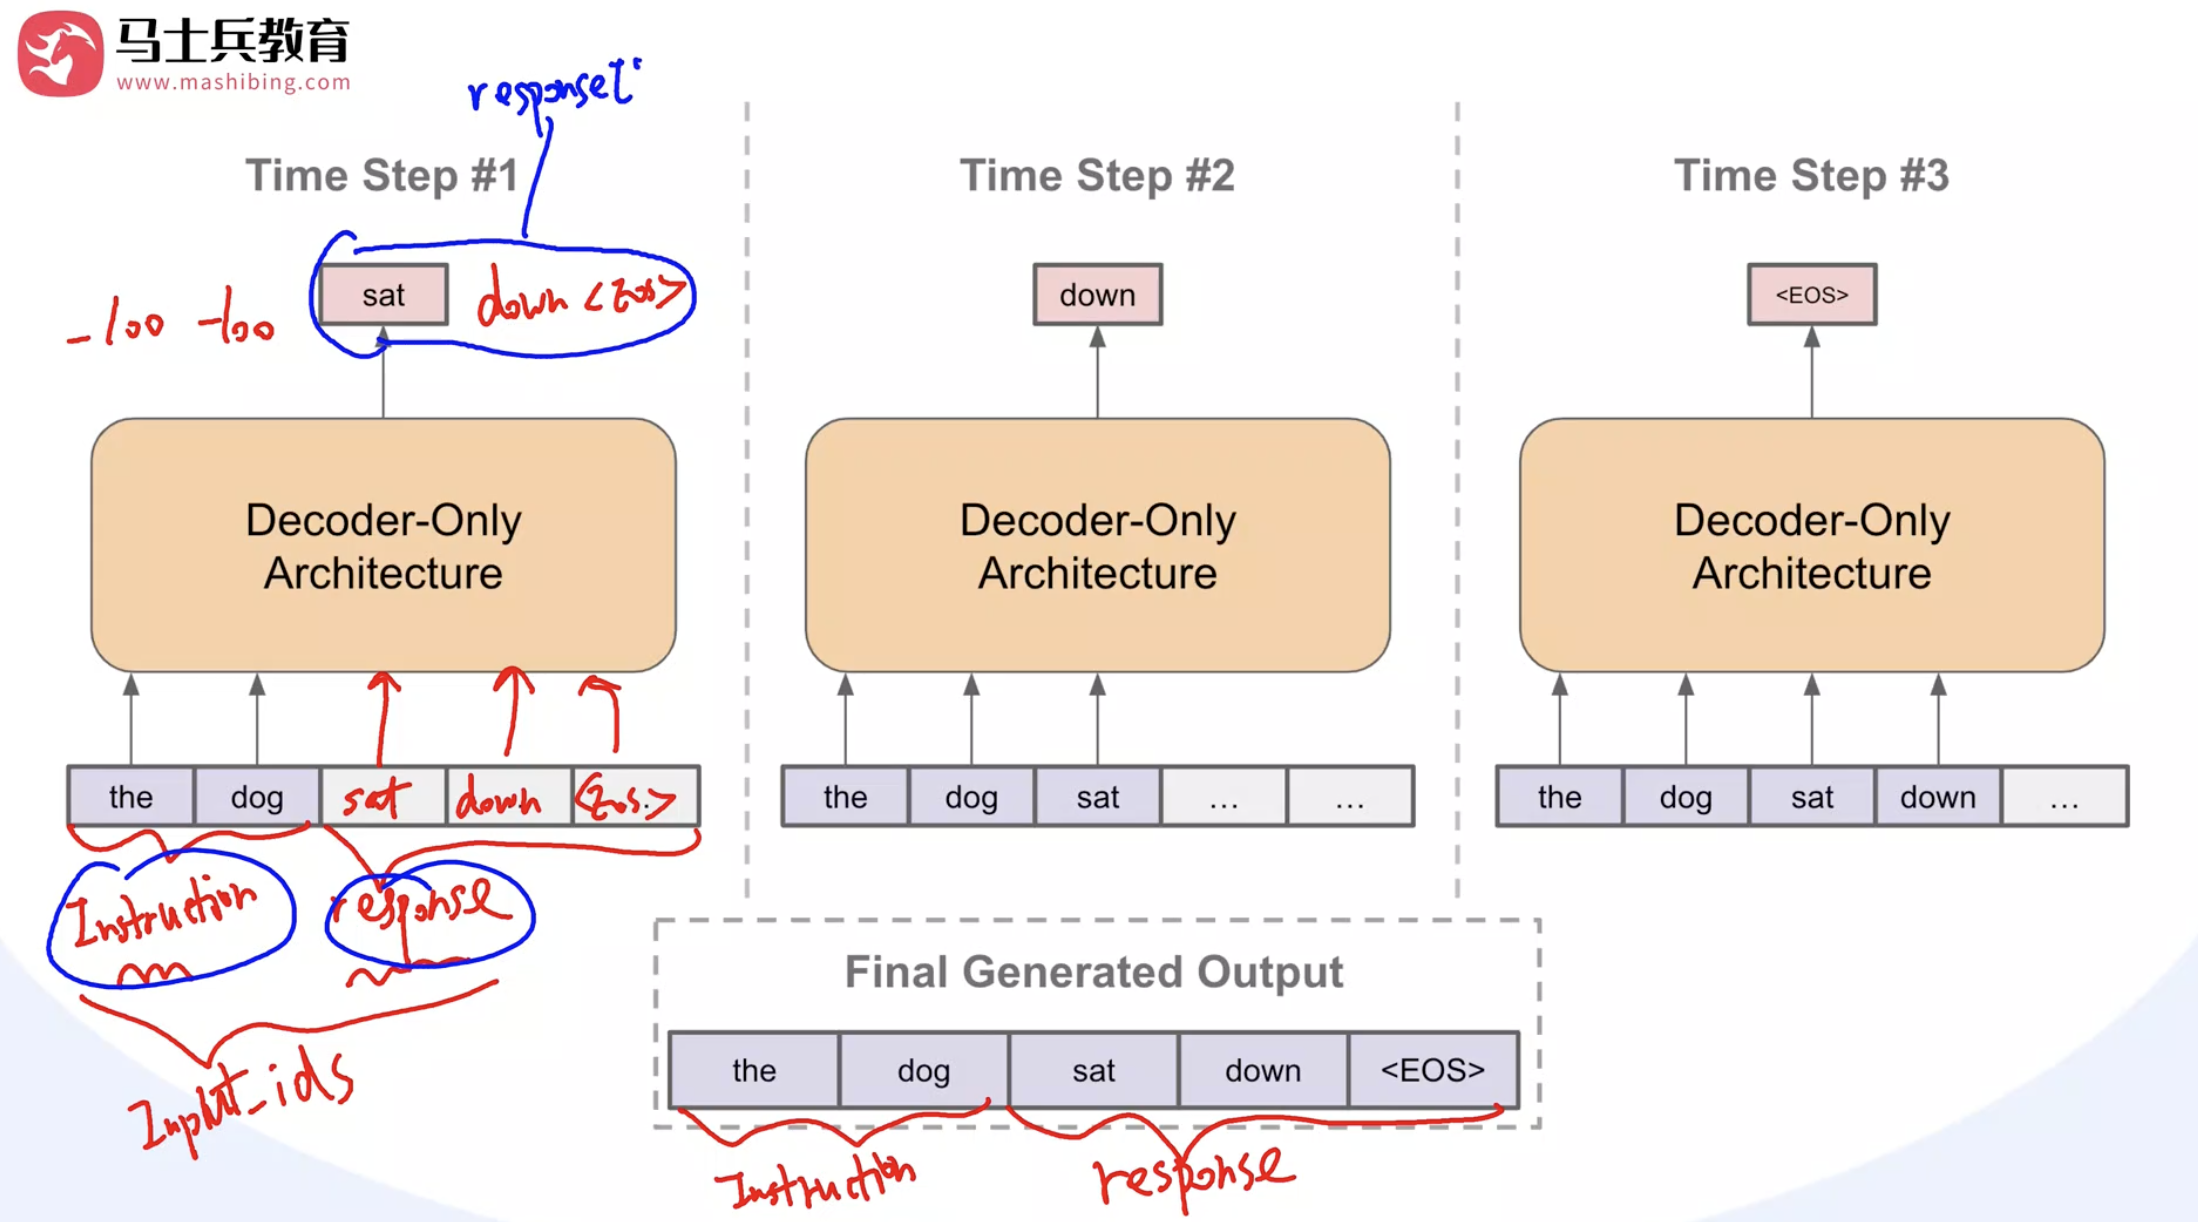

In [8]:
def process_func(example):
    MAX_LENGTH = 256
    # input_ids,attention_mask ,labels= [],[],[]
    # 所有的instruction前面加上Human: 
    instruction = tokenizer(
        "\n".join(["Human: "+example["instruction"], example["input"]]).strip()
        +"\n\nAssistant: ")
    response = tokenizer(example["output"] + tokenizer.eos_token)
    
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    
    # 构建labels序列：instruction部分用-100填充(不计算loss)，response部分使用真实token id
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]
    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
    
    return {
        "input_ids": input_ids,
        "attention_mask":  attention_mask,# transformer中0表示不掩码，1表示需要被mask
        "labels": labels
    }

item = process_func(ds[0])
print('input_ids:',item['input_ids'])
print('attention_mask:',item['attention_mask'])
print('labels:',item['labels'])

input_ids: [26283, 29, 210, 7160, 28215, 9905, 15211, 672, 189, 4340, 17245, 29, 210, 5040, 584, 7160, 28215, 9905, 15211, 1038, 189, 189, 20, 17, 210, 7160, 9239, 3365, 420, 9487, 1965, 15342, 9239, 6053, 355, 1227, 32998, 554, 34487, 1326, 17632, 355, 975, 5189, 39177, 6455, 355, 12144, 17335, 8481, 355, 1437, 12785, 6698, 23294, 672, 189, 21, 17, 210, 22905, 15356, 420, 9487, 15597, 22985, 373, 19320, 554, 18524, 554, 1229, 6663, 1467, 642, 16422, 18235, 27624, 17520, 8732, 355, 8729, 1246, 7110, 554, 1246, 16422, 642, 15224, 11367, 355, 718, 7160, 28215, 15356, 12577, 672, 189, 22, 17, 210, 20027, 18399, 420, 20027, 1079, 15713, 6455, 21230, 355, 34810, 9487, 1688, 8637, 967, 3958, 210, 43738, 20027, 420, 15822, 20027, 12785, 17374, 12115, 355, 5189, 9239, 8113, 355, 1437, 5706, 4202, 19112, 16610, 1276, 420, 2]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [9]:
tokenized_ds = ds.map(process_func,remove_columns = ds.column_names)
tokenized_ds

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 48818
})

## 解码来检查一下是否正确

In [10]:
input_ids = tokenized_ds[0]["input_ids"]

print(tokenizer.decode(input_ids,skip_special_tokens=True))

tokenizer.decode(list( filter( lambda x: x!=-100 , tokenized_ds[0]["labels"])))

Human: 保持健康的三个提示。

Assistant: 以下是保持健康的三个提示：

1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。

2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。

3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。


'以下是保持健康的三个提示：\n\n1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。\n\n2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。\n\n3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。</s>'

# 模型创建

In [11]:
model = AutoModelForCausalLM.from_pretrained(model_path,low_cpu_mem_usage=True)
model

BloomForCausalLM(
  (transformer): BloomModel(
    (word_embeddings): Embedding(46145, 2048)
    (word_embeddings_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (h): ModuleList(
      (0-23): 24 x BloomBlock(
        (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (self_attention): BloomAttention(
          (query_key_value): Linear(in_features=2048, out_features=6144, bias=True)
          (dense): Linear(in_features=2048, out_features=2048, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (post_attention_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (mlp): BloomMLP(
          (dense_h_to_4h): Linear(in_features=2048, out_features=8192, bias=True)
          (gelu_impl): BloomGelu()
          (dense_4h_to_h): Linear(in_features=8192, out_features=2048, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  )
  (l

# BitFit
### 训练优化器
SGD 
with momentum Opimizer \
with Adam Optimizer \
总共大小：

In [12]:
num_param = 0
num_bias = 0
for name,param in model.named_parameters():
    # print(name,param.shape)
    # 没有bias的参数不更新
    if "bias" not in name:
        param.requires_grad = False
    else :
        param.requires_grad = True
        num_bias += param.numel()
    num_param += param.numel()
print('num param:',num_param)
print('num  bias:',num_bias)
print('ratio:',num_bias/num_param)

num param: 1303111680
num  bias: 544768
ratio: 0.000418051659240749


# 配置训练参数

In [13]:
args = TrainingArguments(
    output_dir = './chatbot', # 输出文件夹存储模型的预测结果和模型文件checkpoint
    per_device_train_batch_size = 1, # 默认8,对于每个训练的时候每个gpu或cpu核心上的batch_size
    # per_device_eval_batch_size = 1, # 默认8,对于每个验证的时候每个gpu或cpu核心上的batch_size
    gradient_accumulation_steps=1, # 梯度积累,默认1,每经过多少步进行一次梯度更新
    logging_steps = 2, # 每隔多少步进行日志输出
    num_train_epochs = 10, # 训练的轮数
    weight_decay = 1e-5, # 权重衰减
)

# 创建训练器

In [ ]:
trainer = Trainer(
    model = model,
    args = args,
    train_dataset = tokenized_ds,
    # 构建一个个批次数据所需要的
    data_collator = DataCollatorForSeq2Seq(tokenizer,padding=True),
)
trainer.train()

In [ ]:
from transformers import pipeline
pipe = pipeline("text-generation", model="Qwen/QwQ-32B")
